# Analyse comparative des agents — LineWorld

Ce notebook évalue tous les agents entraînés / configurés sur **LineWorld** (line_world) selon plusieurs métriques. LineWorld est un env mono-joueur ; toutes les parties terminent en succès (reward +1) ou échec (reward -1). Pas de win/draw/loss explicites — le reward moyen capture directement le taux de succès.

## Sources de données

| Source | Mode | Description |
|---|---|---|
| `training_curve.csv` (par run) | TRAINING | Reward épisode-par-épisode pendant l'entraînement (politique ε-greedy en cours d'apprentissage). |
| `metrics_reeval.csv` (par run) | INFERENCE | Re-évaluation par `scripts/evaluate_all.py` : politique gelée à chaque checkpoint, ε=0, argmax greedy. **Source canonique pour les métriques finales.** |
| `metrics.csv` (par run, fallback) | INFERENCE | Eval pendant l'entraînement (mode greedy aussi). Utilisé pour `random` qui n'a pas de checkpoints. |
| `metrics.csv` (planning agents) | INFERENCE | Sweep `budget → score` produit par `scripts/evaluate_planning_agents.py` pour MCTS / RandomRollout. |

## Plan

1. **Inventaire** des runs disponibles
2. **TRAINING** — courbes d'apprentissage (reward par épisode, moyenne glissante)
3. **INFERENCE** — Reward moyen par checkpoint, tous agents superposés
4. **INFERENCE** — Longueur d'épisode (steps) par checkpoint
5. **INFERENCE** — Temps moyen par coup (ms)
6. **INFERENCE** — Comparaison agrégée aux checkpoints clés (bar chart)
7. **INFERENCE** — Best checkpoint par agent (« plus d'épisodes ≠ meilleur »)
8. **INFERENCE** — Termination vs truncation
9. **PLANNING** — Sweep budget → reward / temps pour MCTS et RandomRollout
10. **PARETO** — Temps par coup vs reward
11. **Hyperparamètres** de chaque run
12. **Synthèse finale** — ranking par métrique

> Hypothèse : `uv run scripts/evaluate_all.py --num-games 100` et `uv run scripts/evaluate_planning_agents.py configs_done/{mcts,random_rollout}/line_world.yaml` ont été exécutés.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

# Resolve project root (this notebook lives in notebooks/)
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
RESULTS_DIR = ROOT / "results"

ENV_NAME = "line_world"
ENV_TITLE = "LineWorld"
EXPECTED_CHECKPOINTS = [1000, 10000, 50000]

LEARNING_AGENTS = ["random", "tabular_q", "dqn", "ddqn", "ddqn_er", "ddqn_per"]
PLANNING_AGENTS = ["random_rollout", "mcts"]
ALL_AGENTS_ORDER = LEARNING_AGENTS + PLANNING_AGENTS

cmap = plt.get_cmap("tab10")
AGENT_COLOR = {a: cmap(i % 10) for i, a in enumerate(ALL_AGENTS_ORDER)}

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("ROOT     =", ROOT)
print("ENV      =", ENV_NAME)
print("Results  =", RESULTS_DIR.exists())


ROOT     = /Users/brandontchakaniyungeko/ESGI-dev/5IABD/T2/deep_reinforcement_learning/projet
ENV      = line_world
Results  = True


In [2]:
def discover_runs(env_name: str):
    """Scan results/{env}/{agent}/{run_dir}/ and split learning vs planning runs.

    Skips directories named 'best/' (curated single-checkpoint copies, would duplicate data).
    """
    learning, planning = [], []
    env_path = RESULTS_DIR / env_name
    if not env_path.exists():
        return learning, planning

    for agent_dir in sorted(env_path.iterdir()):
        if not agent_dir.is_dir():
            continue
        agent_name = agent_dir.name
        for run_dir in sorted(agent_dir.iterdir()):
            if not run_dir.is_dir() or run_dir.name == "best":
                continue
            cfg_path = run_dir / "config.yaml"
            if not cfg_path.exists():
                continue
            with open(cfg_path) as f:
                cfg = yaml.safe_load(f) or {}
            entry = {
                "agent": agent_name,
                "run_dir": run_dir,
                "run_name": run_dir.name,
                "seed": cfg.get("seed", ""),
                "config": cfg,
            }
            if run_dir.name.startswith("budget_sweep") or agent_name in PLANNING_AGENTS:
                planning.append(entry)
            else:
                learning.append(entry)
    return learning, planning


def load_training_curve(run_entry):
    p = run_entry["run_dir"] / "training_curve.csv"
    if not p.exists():
        return pd.DataFrame()
    df = pd.read_csv(p)
    df["agent"] = run_entry["agent"]
    df["run_name"] = run_entry["run_name"]
    return df


def load_planning_metrics(run_entry):
    p = run_entry["run_dir"] / "metrics.csv"
    if not p.exists():
        return pd.DataFrame()
    df = pd.read_csv(p)
    df["agent"] = run_entry["agent"]
    df["run_name"] = run_entry["run_name"]
    return df


def load_eval_metrics(run_entry):
    """Single-player schema. Priority: metrics_reeval.csv > metrics.csv (random fallback)."""
    run_dir = run_entry["run_dir"]
    reeval = run_dir / "metrics_reeval.csv"
    fallback = run_dir / "metrics.csv"

    df = None
    if reeval.exists() and reeval.stat().st_size > 0:
        df = pd.read_csv(reeval)
        if df.empty:
            df = None
    if df is None and fallback.exists():
        df = pd.read_csv(fallback)
    if df is None or df.empty:
        return pd.DataFrame()

    df = df.copy()
    df["agent"] = run_entry["agent"]
    df["run_name"] = run_entry["run_name"]
    df["seed"] = run_entry["seed"]
    return df


In [3]:
learning_runs, planning_runs = discover_runs(ENV_NAME)
print(f"Learning runs : {len(learning_runs)}")
for r in learning_runs:
    print(f"  - {r['agent']:10s} seed={r['seed']:<5}  {r['run_name'][:80]}")
print(f"\nPlanning runs : {len(planning_runs)}")
for r in planning_runs:
    print(f"  - {r['agent']:18s} seed={r['seed']:<5}  {r['run_name']}")

eval_frames = [load_eval_metrics(r) for r in learning_runs]
df_eval = pd.concat([f for f in eval_frames if not f.empty], ignore_index=True) if eval_frames else pd.DataFrame()

train_frames = [load_training_curve(r) for r in learning_runs]
df_train = pd.concat([f for f in train_frames if not f.empty], ignore_index=True) if train_frames else pd.DataFrame()

planning_frames = [load_planning_metrics(r) for r in planning_runs]
df_planning = pd.concat([f for f in planning_frames if not f.empty], ignore_index=True) if planning_frames else pd.DataFrame()

print(f"\nINFERENCE eval rows  : {len(df_eval)}")
print(f"TRAINING curve rows  : {len(df_train)}")
print(f"PLANNING sweep rows  : {len(df_planning)}")


Learning runs : 6
  - ddqn       seed=42     batch_size64_buffer_capacity10000_epsilon_decay_steps10000_epsilon_end0.01_epsil
  - ddqn_er    seed=42     batch_size64_buffer_capacity10000_epsilon_decay_steps10000_epsilon_end0.01_epsil
  - ddqn_per   seed=42     batch_size64_buffer_capacity10000_epsilon_decay_steps10000_epsilon_end0.01_epsil
  - dqn        seed=42     batch_size64_buffer_capacity10000_epsilon_decay_steps10000_epsilon_end0.01_epsil
  - random     seed=42     default_seed42
  - tabular_q  seed=42     epsilon_decay_steps5000_epsilon_end0.01_epsilon_start1.0_gamma0.99_lr0.1_seed42

Planning runs : 2
  - mcts               seed=42     budget_sweep_seed42
  - random_rollout     seed=42     budget_sweep_seed42

INFERENCE eval rows  : 18
TRAINING curve rows  : 251000
PLANNING sweep rows  : 12


## 1. Inventaire des runs

In [4]:
inventory_rows = []
for r in learning_runs + planning_runs:
    cfg = r["config"]
    inventory_rows.append({
        "type": "planning" if r in planning_runs else "learning",
        "agent": r["agent"],
        "seed": r["seed"],
        "n_checkpoints": (
            sum(1 for p in r["run_dir"].glob("model_*.pt"))
            if r in learning_runs else "-"
        ),
        "n_episodes_trained": cfg.get("training", {}).get("num_episodes", "-"),
        "run_name_short": r["run_name"][:60] + ("..." if len(r["run_name"]) > 60 else ""),
    })
inv = pd.DataFrame(inventory_rows)
inv


,type,agent,seed,n_checkpoints,n_episodes_trained,run_name_short
0,learning,ddqn,42,3,50000,batch_size64_buffer_capacity10000_epsilon_deca...
1,learning,ddqn_er,42,3,50000,batch_size64_buffer_capacity10000_epsilon_deca...
2,learning,ddqn_per,42,3,50000,batch_size64_buffer_capacity10000_epsilon_deca...
3,learning,dqn,42,3,50000,batch_size64_buffer_capacity10000_epsilon_deca...
4,learning,random,42,0,1000,default_seed42
5,learning,tabular_q,42,3,50000,epsilon_decay_steps5000_epsilon_end0.01_epsilo...
6,planning,mcts,42,-,-,budget_sweep_seed42
7,planning,random_rollout,42,-,-,budget_sweep_seed42


## 2. [TRAINING] Courbes d'apprentissage

Reward par épisode pendant l'entraînement (mode ε-greedy, exploration active). On affiche une **moyenne glissante** sur 200 épisodes pour lisser le bruit. Random est plat (ε non pertinent), les Q-learning convergent vers un plateau.

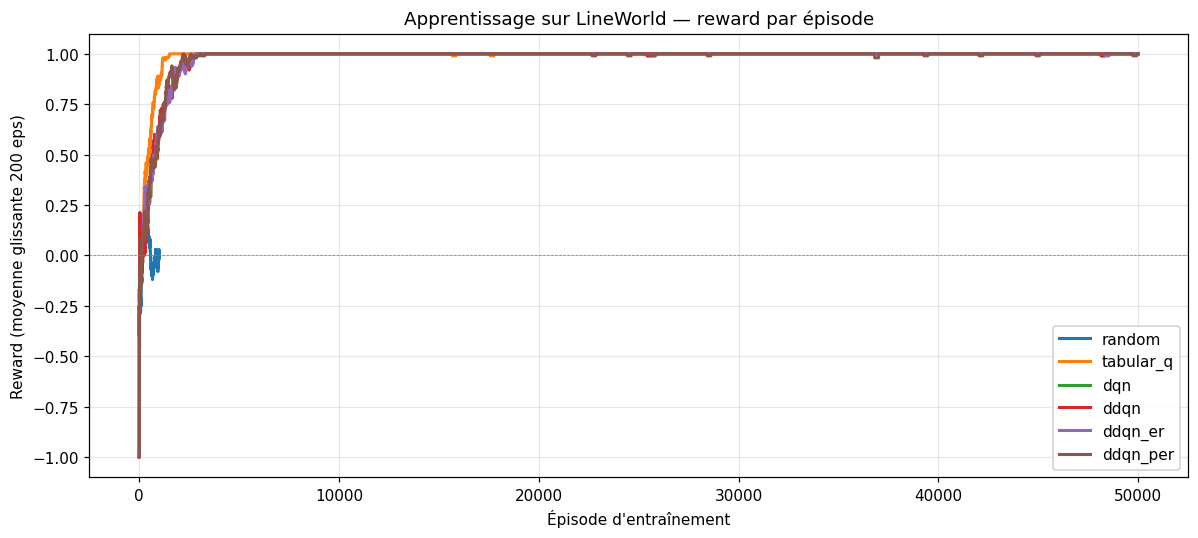

In [5]:
WINDOW = 200

if df_train.empty:
    print("No training curves found.")
else:
    fig, ax = plt.subplots(figsize=(11, 5))
    for agent in [a for a in LEARNING_AGENTS if a in df_train["agent"].unique()]:
        sub = df_train[df_train["agent"] == agent].copy()
        first_run = sub["run_name"].iloc[0]
        sub = sub[sub["run_name"] == first_run].sort_values("episode")
        if len(sub) == 0:
            continue
        smoothed = sub["reward"].rolling(WINDOW, min_periods=1).mean()
        ax.plot(sub["episode"], smoothed, label=agent, color=AGENT_COLOR[agent], linewidth=2)
    ax.set_xlabel("Épisode d'entraînement")
    ax.set_ylabel(f"Reward (moyenne glissante {WINDOW} eps)")
    ax.set_title(f"Apprentissage sur {ENV_TITLE} — reward par épisode")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.legend(loc="best", framealpha=0.9)
    plt.tight_layout()
    plt.show()


## 3. [INFERENCE] Reward moyen par checkpoint

Politique gelée, 100 parties par checkpoint. Une courbe par agent. **Si la courbe descend après un certain checkpoint → l'agent a régressé** (overfit, instabilité, divergence).

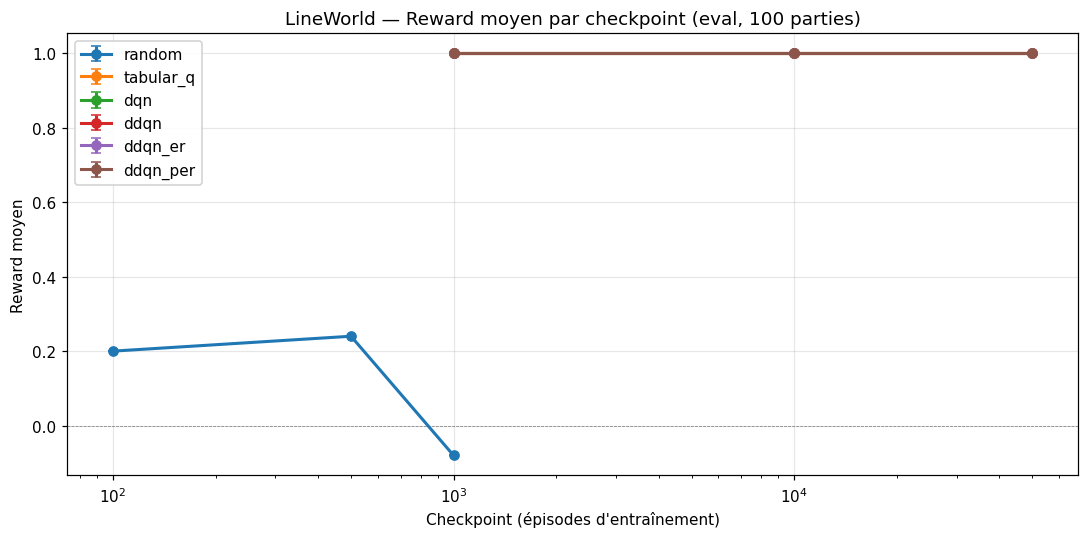

In [6]:
if df_eval.empty:
    print("No eval data.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    for agent in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
        sub = df_eval[df_eval["agent"] == agent].sort_values("checkpoint")
        # Average across seeds if multiple
        agg = sub.groupby("checkpoint", as_index=False).agg(
            mean_reward=("mean_reward", "mean"),
            std_reward=("mean_reward", "std"),
        ).fillna(0)
        ax.errorbar(
            agg["checkpoint"], agg["mean_reward"],
            yerr=agg["std_reward"],
            label=agent, color=AGENT_COLOR[agent], marker="o", capsize=3, linewidth=2,
        )
    ax.set_xlabel("Checkpoint (épisodes d'entraînement)")
    ax.set_ylabel("Reward moyen")
    ax.set_title(f"{ENV_TITLE} — Reward moyen par checkpoint (eval, 100 parties)")
    ax.set_xscale("log")
    ax.legend(loc="best", framealpha=0.9)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    plt.tight_layout()
    plt.show()


## 7. [INFERENCE] Longueur d'épisode (steps)

Combien de pas faut-il à l'agent pour finir un épisode (en moyenne sur 100 parties).

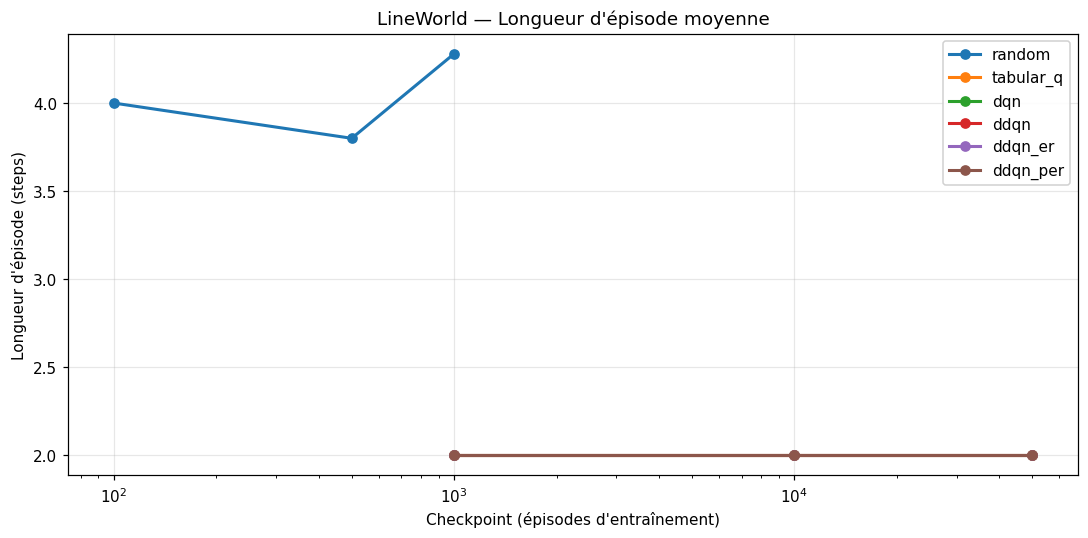

In [7]:
if df_eval.empty:
    print("No eval data.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    for agent in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
        sub = df_eval[df_eval["agent"] == agent].sort_values("checkpoint")
        agg = sub.groupby("checkpoint", as_index=False)["mean_steps"].mean()
        ax.plot(agg["checkpoint"], agg["mean_steps"],
                label=agent, color=AGENT_COLOR[agent], marker="o", linewidth=2)
    ax.set_xlabel("Checkpoint (épisodes d'entraînement)")
    ax.set_ylabel("Longueur d'épisode (steps)")
    ax.set_title(f"{ENV_TITLE} — Longueur d'épisode moyenne")
    ax.set_xscale("log")
    ax.legend(loc="best", framealpha=0.9)
    plt.tight_layout()
    plt.show()


## 8. [INFERENCE] Temps par coup (ms)

Latence d'inférence : combien de temps prend `agent.act(state)`. C'est la métrique demandée par le syllabus (« temps moyen mis pour exécuter un coup »).

On affiche le temps moyen au **dernier checkpoint** de chaque agent apprenant.

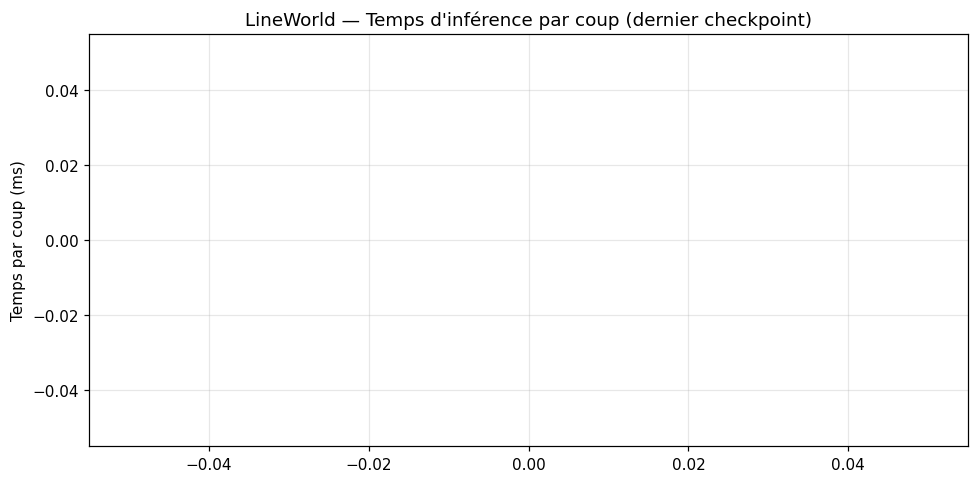

,mean_action_time_ms
agent,


In [8]:
if df_eval.empty:
    print("No eval data.")
else:
    last = df_eval.sort_values("checkpoint").groupby("agent").tail(1)
    last = last.set_index("agent").reindex([a for a in LEARNING_AGENTS if a in last.index])
    fig, ax = plt.subplots(figsize=(9, 4.5))
    bars = ax.bar(last.index, last["mean_action_time_ms"],
                  color=[AGENT_COLOR[a] for a in last.index], edgecolor="black")
    for b, v in zip(bars, last["mean_action_time_ms"]):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("Temps par coup (ms)")
    ax.set_title(f"{ENV_TITLE} — Temps d'inférence par coup (dernier checkpoint)")
    plt.tight_layout()
    plt.show()
    display(last[["mean_action_time_ms"]].round(4))


## 9. [INFERENCE] Comparaison aux checkpoints du syllabus

Bar chart groupé : **Reward moyen** pour chaque agent à chaque checkpoint clé. C'est le format direct demandé par le prof.

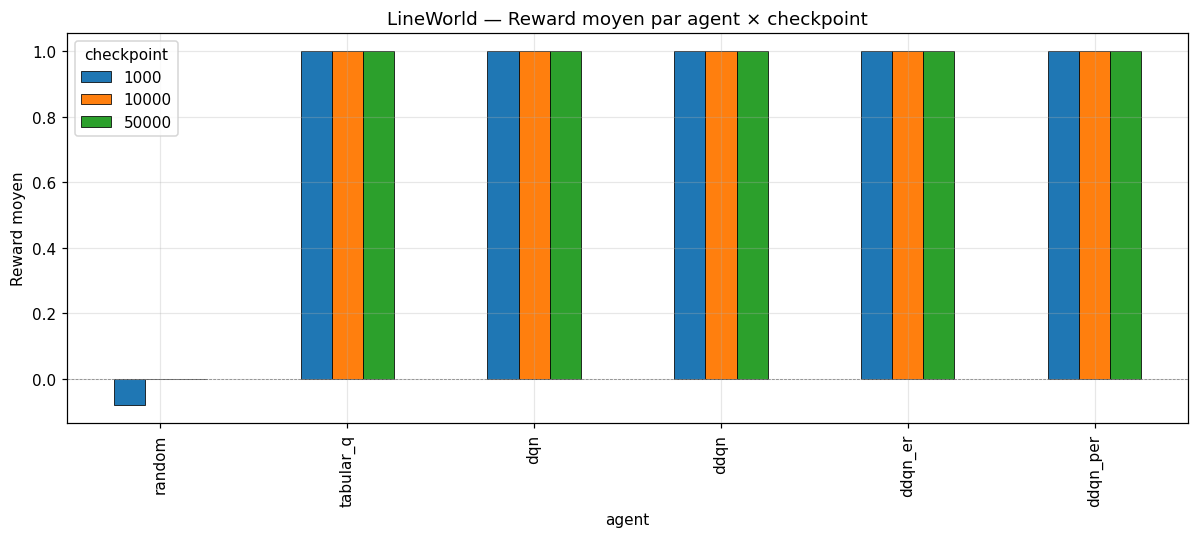

checkpoint,1000,10000,50000
agent,,,
random,-0.0800,NaN,NaN
tabular_q,1.0000,1.0000,1.0000
dqn,1.0000,1.0000,1.0000
ddqn,1.0000,1.0000,1.0000
ddqn_er,1.0000,1.0000,1.0000
ddqn_per,1.0000,1.0000,1.0000


In [9]:
if df_eval.empty:
    print("No eval data.")
else:
    available = sorted(set(df_eval["checkpoint"].unique()) & set(EXPECTED_CHECKPOINTS))
    if not available:
        print("Aucun des checkpoints attendus n'est présent.")
    else:
        present_agents = [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]
        pivot = (df_eval[df_eval["checkpoint"].isin(available)]
                 .pivot_table(index="agent", columns="checkpoint",
                              values="mean_reward", aggfunc="mean")
                 .reindex(present_agents))
        ax = pivot.plot(kind="bar", figsize=(11, 5),
                        edgecolor="black", linewidth=0.5)
        ax.set_ylabel("Reward moyen")
        ax.set_title(f"{ENV_TITLE} — Reward moyen par agent × checkpoint")
        ax.legend(title="checkpoint", loc="best")
        ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
        plt.tight_layout()
        plt.show()
        display(pivot.round(3))


## 10. [INFERENCE] Best checkpoint par agent

**« Plus d'épisodes ≠ meilleur résultat. »** Pour chaque agent on identifie le checkpoint qui maximise le **reward** (ties cassés par longueur d'épisode plus courte). Cela permet de détecter les agents qui régressent en fin d'entraînement.

,best_checkpoint,best_mean_reward,best_steps,last_checkpoint,last_mean_reward,regressed?
agent,,,,,,
random,500,0.2400,3.8000,1000,-0.0800,YES
tabular_q,1000,1.0000,2.0000,50000,1.0000,no
dqn,1000,1.0000,2.0000,50000,1.0000,no
ddqn,1000,1.0000,2.0000,50000,1.0000,no
ddqn_er,1000,1.0000,2.0000,50000,1.0000,no
ddqn_per,1000,1.0000,2.0000,50000,1.0000,no


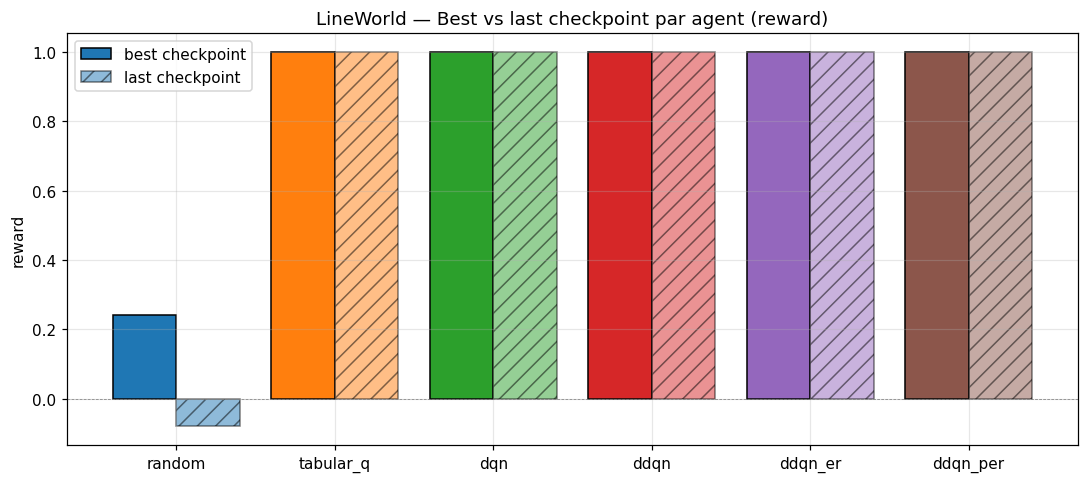

In [10]:
if df_eval.empty:
    print("No eval data.")
else:
    best_rows = []
    for agent in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
        sub = df_eval[df_eval["agent"] == agent].copy()
        sub = sub.sort_values(["mean_reward", "mean_steps"], ascending=[False, True])
        if sub["mean_reward"].dropna().empty:
            continue
        best = sub.iloc[0]
        last = df_eval[df_eval["agent"] == agent].sort_values("checkpoint").iloc[-1]
        best_rows.append({
            "agent": agent,
            "best_checkpoint": int(best["checkpoint"]),
            f"best_mean_reward": best["mean_reward"],
            "best_steps": best["mean_steps"],
            "last_checkpoint": int(last["checkpoint"]),
            f"last_mean_reward": last["mean_reward"],
            "regressed?": "YES" if best["mean_reward"] > last["mean_reward"] + 1e-6 else "no",
        })
    if not best_rows:
        print("Pas de données exploitable pour mean_reward.")
    else:
        best_df = pd.DataFrame(best_rows).set_index("agent")
        display(best_df.round(4))

        fig, ax = plt.subplots(figsize=(10, 4.5))
        x = np.arange(len(best_df))
        w = 0.4
        ax.bar(x - w/2, best_df[f"best_mean_reward"], w, label="best checkpoint",
               color=[AGENT_COLOR[a] for a in best_df.index], edgecolor="black")
        ax.bar(x + w/2, best_df[f"last_mean_reward"], w, label="last checkpoint",
               color=[AGENT_COLOR[a] for a in best_df.index],
               alpha=0.5, edgecolor="black", hatch="//")
        ax.set_xticks(x)
        ax.set_xticklabels(best_df.index)
        ax.set_ylabel("reward")
        ax.set_title(f"{ENV_TITLE} — Best vs last checkpoint par agent (reward)")
        ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
        ax.legend()
        plt.tight_layout()
        plt.show()


## 11. [INFERENCE] Termination vs truncation

- **terminated** : la partie s'est finie proprement (`done=True`) avant la limite `max_steps=10_000`.
- **truncated** : la politique est restée bloquée et l'évaluateur a dû couper.

Un agent qui « gagne 0% des parties » à cause de truncation est très différent d'un agent qui perd réellement.

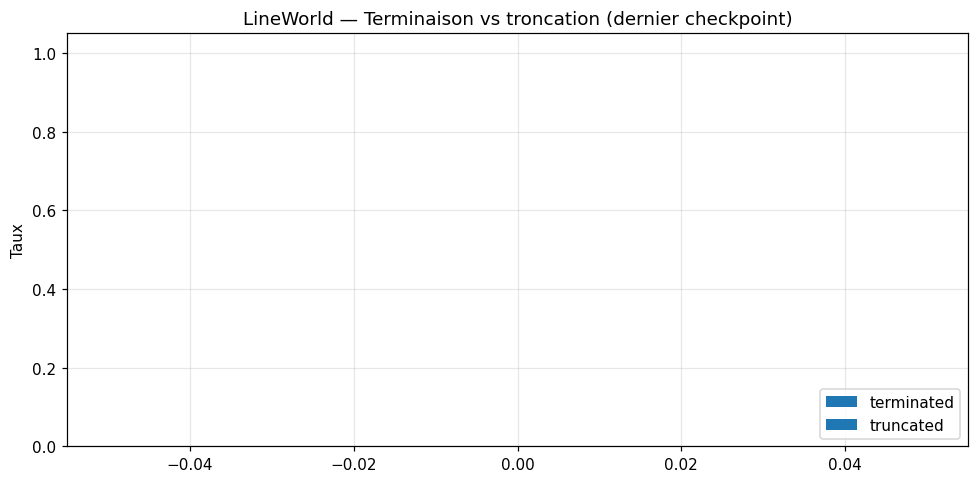

,termination_rate,truncation_rate
agent,,


In [11]:
if df_eval.empty:
    print("No eval data.")
else:
    last = df_eval.sort_values("checkpoint").groupby("agent").tail(1)
    last = last.set_index("agent").reindex([a for a in LEARNING_AGENTS if a in last.index])
    if "termination_rate" not in last.columns:
        print("Pas de colonne termination_rate.")
    else:
        last = last.fillna({"termination_rate": 0, "truncation_rate": 0})
        fig, ax = plt.subplots(figsize=(9, 4.5))
        ax.bar(last.index, last["termination_rate"], label="terminated",
               color="#4CAF50", edgecolor="black")
        ax.bar(last.index, last["truncation_rate"],
               bottom=last["termination_rate"], label="truncated",
               color="#F44336", edgecolor="black")
        ax.set_ylabel("Taux")
        ax.set_ylim(0, 1.05)
        ax.set_title(f"{ENV_TITLE} — Terminaison vs troncation (dernier checkpoint)")
        ax.legend(loc="lower right")
        plt.tight_layout()
        plt.show()
        display(last[["termination_rate", "truncation_rate"]].round(3))


## 12. [PLANNING] MCTS et RandomRollout — sweep budget

Les agents de planification ne s'entraînent pas. Leur axe pertinent est le **budget de simulations par coup**. On observe :
- l'amélioration du Reward moyen avec le budget (jusqu'à saturation),
- l'augmentation linéaire du temps par coup (= le coût direct de la planification).

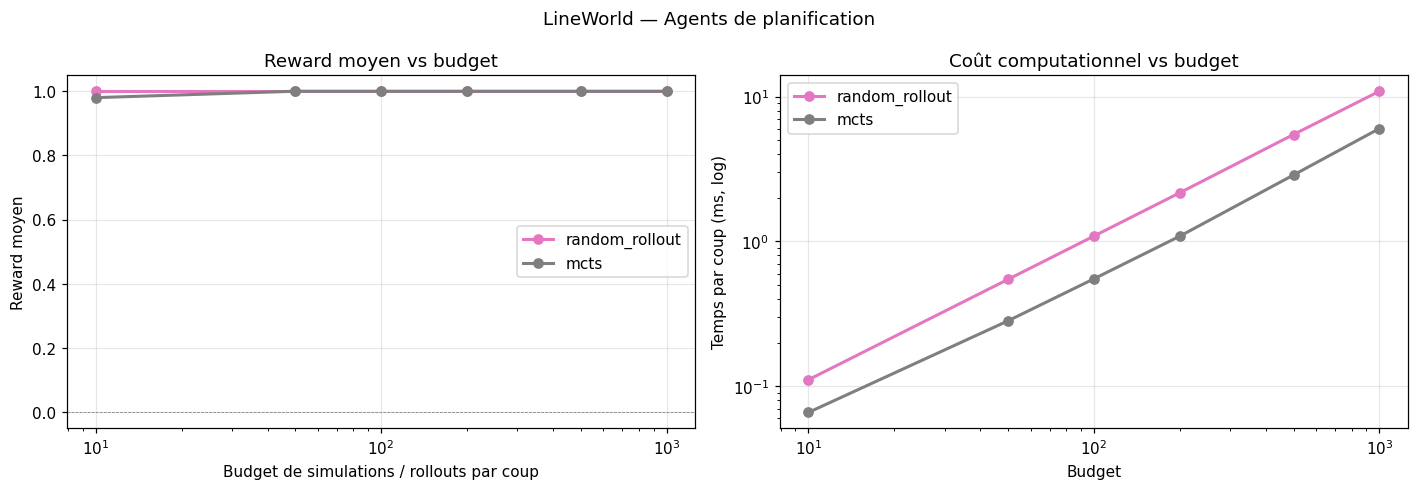

,agent,budget,mean_reward,mean_steps,mean_action_time_ms
0,mcts,10,0.9800,2.2000,0.0660
1,mcts,50,1.0000,2.0400,0.2830
2,mcts,100,1.0000,2.0800,0.5520
3,mcts,200,1.0000,2.0200,1.0880
4,mcts,500,1.0000,2.0000,2.8750
5,mcts,1000,1.0000,2.0000,6.0200
6,random_rollout,10,1.0000,2.0400,0.1110
7,random_rollout,50,1.0000,2.0000,0.5470
8,random_rollout,100,1.0000,2.0000,1.0890
9,random_rollout,200,1.0000,2.0000,2.1690


In [12]:
if df_planning.empty:
    print("Pas de données planning. Lance:")
    print("  uv run scripts/evaluate_planning_agents.py configs_done/mcts/" + ENV_NAME + ".yaml")
    print("  uv run scripts/evaluate_planning_agents.py configs_done/random_rollout/" + ENV_NAME + ".yaml")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for agent in [a for a in PLANNING_AGENTS if a in df_planning["agent"].unique()]:
        sub = df_planning[df_planning["agent"] == agent].sort_values("budget")
        if "mean_reward" not in sub.columns or sub["mean_reward"].isna().all():
            continue
        axes[0].plot(sub["budget"], sub["mean_reward"],
                     label=agent, color=AGENT_COLOR[agent], marker="o", linewidth=2)
        axes[1].plot(sub["budget"], sub["mean_action_time_ms"],
                     label=agent, color=AGENT_COLOR[agent], marker="o", linewidth=2)
    axes[0].set_xscale("log")
    axes[0].set_xlabel("Budget de simulations / rollouts par coup")
    axes[0].set_ylabel("Reward moyen")
    axes[0].set_title("Reward moyen vs budget")
    axes[0].legend()
    axes[0].axhline(0, color="gray", linewidth=0.5, linestyle="--")
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Budget")
    axes[1].set_ylabel("Temps par coup (ms, log)")
    axes[1].set_title("Coût computationnel vs budget")
    axes[1].legend()
    plt.suptitle(f"{ENV_TITLE} — Agents de planification")
    plt.tight_layout()
    plt.show()
    cols = ["agent", "budget", "mean_reward", "mean_steps", "mean_action_time_ms"]
    cols = [c for c in cols if c in df_planning.columns]
    display(df_planning[cols].sort_values(["agent", "budget"]).reset_index(drop=True))


## 13. [PARETO] Compromis temps/coup vs Reward moyen

Chaque point = un (agent, checkpoint ou budget). On cherche le coin **haut-gauche** : Reward moyen élevé, temps faible. C'est utile pour un déploiement temps-réel.

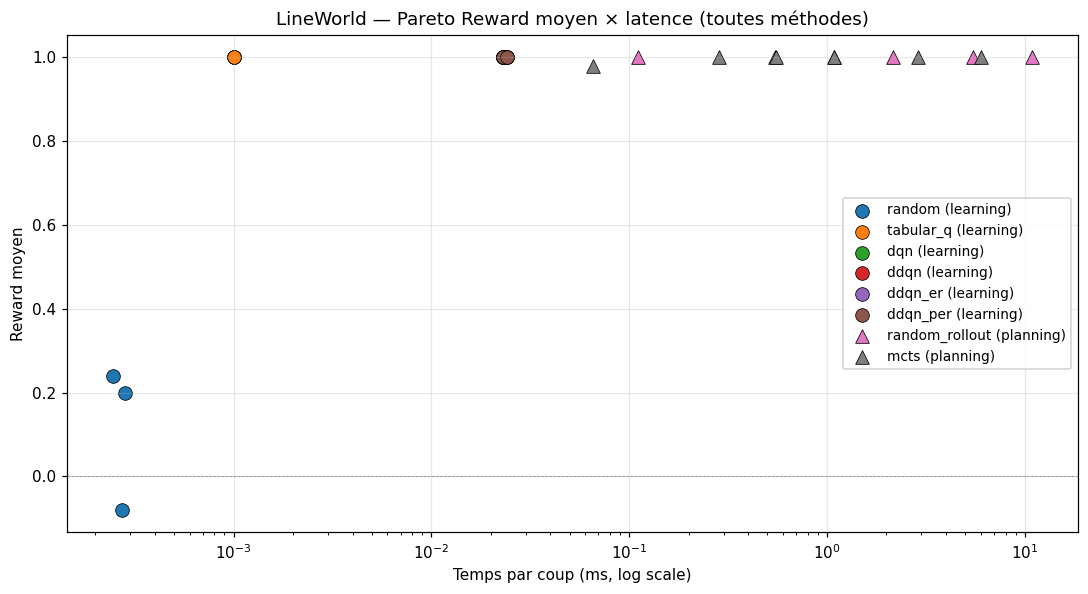

In [13]:
fig, ax = plt.subplots(figsize=(10, 5.5))

if not df_eval.empty and "mean_reward" in df_eval.columns:
    for agent in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
        sub = df_eval[df_eval["agent"] == agent].dropna(subset=["mean_reward"])
        if sub.empty:
            continue
        ax.scatter(sub["mean_action_time_ms"], sub["mean_reward"],
                   s=80, color=AGENT_COLOR[agent], label=f"{agent} (learning)",
                   edgecolor="black", linewidth=0.5)

if not df_planning.empty:
    for agent in [a for a in PLANNING_AGENTS if a in df_planning["agent"].unique()]:
        sub = df_planning[df_planning["agent"] == agent]
        if "mean_reward" not in sub.columns or sub["mean_reward"].isna().all():
            continue
        ax.scatter(sub["mean_action_time_ms"], sub["mean_reward"],
                   s=80, color=AGENT_COLOR[agent], label=f"{agent} (planning)",
                   marker="^", edgecolor="black", linewidth=0.5)

ax.set_xscale("log")
ax.set_xlabel("Temps par coup (ms, log scale)")
ax.set_ylabel("Reward moyen")
ax.set_title(f"{ENV_TITLE} — Pareto Reward moyen × latence (toutes méthodes)")
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.legend(loc="best", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()


## 14. Hyperparamètres de chaque run

Snapshot des hyperparamètres tels qu'utilisés pendant l'entraînement (lus depuis `results/<env>/<agent>/<run>/config.yaml`).

In [14]:
hparam_rows = []
for r in learning_runs + planning_runs:
    cfg = r["config"]
    flat = {"agent": r["agent"], "seed": cfg.get("seed", "")}
    for k, v in cfg.get("agent_params", {}).items():
        flat[f"ap.{k}"] = v
    if "training" in cfg:
        flat["num_episodes"] = cfg["training"].get("num_episodes", "")
    if "budgets" in cfg:
        flat["budgets"] = str(cfg["budgets"])
    hparam_rows.append(flat)
hp = pd.DataFrame(hparam_rows).set_index("agent")
hp


,seed,ap.batch_size,ap.buffer_capacity,ap.epsilon_decay_steps,ap.epsilon_end,ap.epsilon_start,ap.gamma,ap.hidden_layers,ap.lr,ap.target_update_freq,...,ap.learning_starts,ap.per_alpha,ap.per_beta_end,ap.per_beta_start,ap.per_beta_steps,ap.c_uct,ap.max_rollout_depth,ap.n_simulations,budgets,ap.n_rollouts_per_action
agent,,,,,,,,,,,,,,,,,,,,,
ddqn,42,64.0000,10000.0000,10000.0000,0.0100,1.0000,0.9900,"[64, 64]",0.0010,100.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ddqn_er,42,64.0000,10000.0000,10000.0000,0.0100,1.0000,0.9900,"[64, 64]",0.0010,100.0000,...,500.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ddqn_per,42,64.0000,10000.0000,10000.0000,0.0100,1.0000,0.9900,"[64, 64]",0.0010,100.0000,...,500.0000,0.6000,1.0000,0.4000,50000.0000,NaN,NaN,NaN,NaN,NaN
dqn,42,64.0000,10000.0000,10000.0000,0.0100,1.0000,0.9900,"[64, 64]",0.0010,100.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
random,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tabular_q,42,NaN,NaN,5000.0000,0.0100,1.0000,0.9900,NaN,0.1000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mcts,42,NaN,NaN,NaN,NaN,NaN,1.0000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.4100,100.0000,50.0000,"[10, 50, 100, 200, 500, 1000]",NaN
random_rollout,42,NaN,NaN,NaN,NaN,NaN,1.0000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,100.0000,NaN,"[10, 50, 100, 200, 500, 1000]",100.0000


## 15. Synthèse — ranking final par reward

Tableau trié par **reward** (au best checkpoint pour les apprenants, au plus gros budget pour planning). On rapporte aussi le temps par coup pour départager.

In [15]:
rows = []

if not df_eval.empty and "mean_reward" in df_eval.columns:
    for agent in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
        sub = df_eval[df_eval["agent"] == agent].dropna(subset=["mean_reward"]).copy()
        if sub.empty:
            continue
        sub = sub.sort_values(["mean_reward", "mean_steps"], ascending=[False, True])
        best = sub.iloc[0]
        rows.append({
            "method": agent,
            "kind": "learning",
            "config_point": f"ckpt={int(best['checkpoint'])}",
            "mean_reward": best["mean_reward"],
            "mean_reward": best.get("mean_reward", float("nan")),
            "mean_steps": best["mean_steps"],
            "mean_action_time_ms": best["mean_action_time_ms"],
            "termination_rate": best.get("termination_rate", float("nan")),
        })

if not df_planning.empty:
    for agent in [a for a in PLANNING_AGENTS if a in df_planning["agent"].unique()]:
        sub = df_planning[df_planning["agent"] == agent].copy()
        if "mean_reward" not in sub.columns or sub["mean_reward"].isna().all():
            continue
        sub = sub.sort_values(["mean_reward", "budget"], ascending=[False, True])
        best = sub.iloc[0]
        rows.append({
            "method": agent,
            "kind": "planning",
            "config_point": f"budget={int(best['budget'])}",
            "mean_reward": best["mean_reward"],
            "mean_reward": best.get("mean_reward", float("nan")),
            "mean_steps": best["mean_steps"],
            "mean_action_time_ms": best["mean_action_time_ms"],
            "termination_rate": best.get("termination_rate", float("nan")),
        })

if not rows:
    print("No data to rank.")
else:
    ranking = pd.DataFrame(rows).sort_values(
        ["mean_reward", "mean_action_time_ms"], ascending=[False, True]
    ).reset_index(drop=True)
    ranking.index = ranking.index + 1
    ranking.index.name = "rank"
    display(ranking.round(4))


,method,kind,config_point,mean_reward,mean_steps,mean_action_time_ms,termination_rate
rank,,,,,,,
1,tabular_q,learning,ckpt=1000,1.0000,2.0000,0.0010,1.0000
2,ddqn_er,learning,ckpt=1000,1.0000,2.0000,0.0230,1.0000
3,ddqn_per,learning,ckpt=1000,1.0000,2.0000,0.0230,1.0000
4,dqn,learning,ckpt=1000,1.0000,2.0000,0.0240,1.0000
5,ddqn,learning,ckpt=1000,1.0000,2.0000,0.0240,1.0000
6,random_rollout,planning,budget=10,1.0000,2.0400,0.1110,1.0000
7,mcts,planning,budget=50,1.0000,2.0400,0.2830,1.0000
8,random,learning,ckpt=500,0.2400,3.8000,0.0002,NaN
